Engagement Metrics Preview:
   customer_id  weekly_visits  session_time_minutes  page_views  app_opens
0            1              8                 17.61        16.0          6
1            2              3                 12.93         9.0          2
2            3             14                 20.70        56.0         12
3            4              6                 11.53        24.0          6
4            5              5                  7.87        10.0          4

Weekly Visits Distribution:
count    10000.000000
mean         7.673300
std          4.687704
min          0.000000
25%          4.000000
50%          7.000000
75%         10.000000
max         38.000000
Name: weekly_visits, dtype: float64

Session Time Distribution:
count    9803.000000
mean       16.082930
std         5.597279
min        -5.380000
25%        12.295000
50%        15.990000
75%        19.720000
max        41.870000
Name: session_time_minutes, dtype: float64

Correlation between engagement metrics:
 

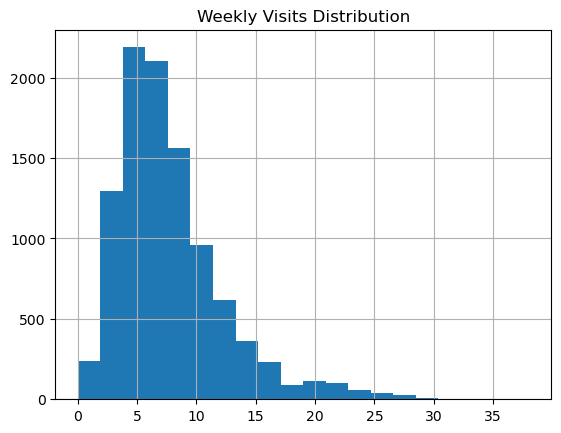

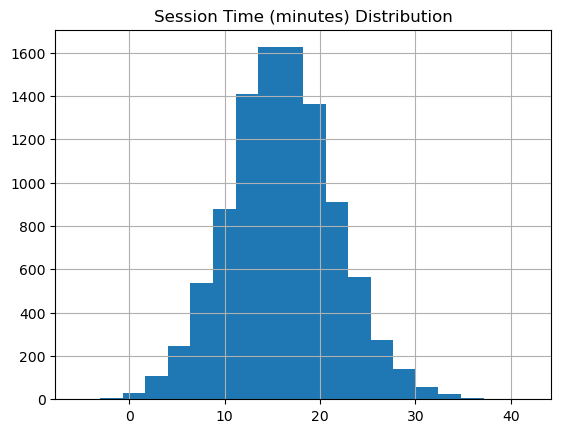

In [1]:
# Step 0: Imports and setup
import pandas as pd
import numpy as np
import random
from faker import Faker
import matplotlib.pyplot as plt

# Seeds for reproducibility
Faker.seed(42)
np.random.seed(42)
random.seed(42)
fake = Faker()

# -----------------------------
# Step 1: Recreate Customer Profiles (Step 1 inside Step 3)
# -----------------------------
num_customers = 10000

customer_ids = np.arange(1, num_customers+1)
countries = ['USA','EU','Asia','Other']
country_probs = [0.4,0.3,0.2,0.1]
customer_country = np.random.choice(countries, size=num_customers, p=country_probs)
names = [fake.name() for _ in range(num_customers)]
genders = np.random.choice(['M','F','Other'], size=num_customers, p=[0.49,0.49,0.02])
ages = np.clip(np.random.normal(33,10,num_customers),18,65).astype(int)
tiers = ['Bronze','Silver','Gold','Platinum']
tier_probs = [0.5,0.3,0.15,0.05]
customer_tier = np.random.choice(tiers, size=num_customers, p=tier_probs)

# Assemble DataFrame
customer_profiles = pd.DataFrame({
    'customer_id': customer_ids,
    'name': names,
    'gender': genders,
    'age': ages,
    'country': customer_country,
    'customer_tier': customer_tier
})

# -----------------------------
# Step 2: Recreate Purchase History (Step 2 inside Step 3)
# -----------------------------
avg_orders_per_customer = 10
order_multiplier = np.random.poisson(lam=avg_orders_per_customer, size=num_customers)
orders_list = []
order_id_counter = 1
product_categories = ['Electronics','Clothing','Home','Books','Toys','Beauty','Sports','Grocery','Automotive','Jewelry']

for idx, customer_id in enumerate(customer_profiles['customer_id']):
    num_orders = max(1, order_multiplier[idx])
    tier = customer_profiles.loc[idx, 'customer_tier']
    for _ in range(num_orders):
        order_amount = np.random.lognormal(mean=3.5, sigma=0.5)*{'Bronze':1,'Silver':1.5,'Gold':2,'Platinum':3}[tier]
        if np.random.rand()<0.01:  # rare outlier
            order_amount*=10
        orders_list.append({'order_id':order_id_counter,'customer_id':customer_id,'order_amount':round(order_amount,2)})
        order_id_counter+=1

purchase_history = pd.DataFrame(orders_list)

# -----------------------------
# Step 3: Generate Engagement Metrics
# -----------------------------
engagement_list = []

for idx, row in customer_profiles.iterrows():
    customer_id = row['customer_id']
    tier = row['customer_tier']
    # Tier-weighted engagement: Platinum > Gold > Silver > Bronze
    base_visits = {'Bronze':5,'Silver':8,'Gold':12,'Platinum':20}[tier]
    weekly_visits = np.random.poisson(base_visits, 1)[0]
    session_time = np.random.normal(15,5,1)[0] * (1 + ['Bronze','Silver','Gold','Platinum'].index(tier)*0.1)  # in minutes
    page_views = weekly_visits* np.random.randint(2,5)
    app_opens = max(1,int(weekly_visits*np.random.uniform(0.7,1.3)))
    
    # Rare missing values
    if np.random.rand()<0.02:
        session_time = np.nan
    if np.random.rand()<0.02:
        page_views = np.nan
    
    engagement_list.append({
        'customer_id': customer_id,
        'weekly_visits': weekly_visits,
        'session_time_minutes': round(session_time,2),
        'page_views': page_views,
        'app_opens': app_opens
    })

engagement_behavior = pd.DataFrame(engagement_list)

# -----------------------------
# Step 4: Validation
# -----------------------------
print("Engagement Metrics Preview:")
print(engagement_behavior.head())

print("\nWeekly Visits Distribution:")
print(engagement_behavior['weekly_visits'].describe())

print("\nSession Time Distribution:")
print(engagement_behavior['session_time_minutes'].describe())

print("\nCorrelation between engagement metrics:")
print(engagement_behavior[['weekly_visits','session_time_minutes','page_views','app_opens']].corr())

# Histograms
engagement_behavior['weekly_visits'].hist(bins=20)
plt.title("Weekly Visits Distribution")
plt.show()

engagement_behavior['session_time_minutes'].hist(bins=20)
plt.title("Session Time (minutes) Distribution")
plt.show()

In [2]:
engagement_behavior.to_csv('../data/engagement_behavior_10k.csv', index=False)
print("engagement_behavior_10k.csv saved!")

engagement_behavior_10k.csv saved!
